
# 06. 말투 세계: 사다리 1단계 졸업 시험

**질문**: 사람이 정한 칸(문, 열쇠, 열린다/안 열린다)에 안 들어가는 정보가 있을 때, 스스로 배운 연결이 그 정보를 꺼내 써서 칸 방식을 이길까?

**세계**: 원래 세계와 똑같고, 문장 앞에 말투만 붙였다.
- 확신: "확실한데, …" → 맞는 말일 때 더 자주 나온다
- 보통: 앞말 없음
- 망설임: "잘은 모르겠는데, …" → 틀린 말일 때 더 자주 나온다

| 비교 대상 | 읽기 | 말투 |
|---|---|---|
| 칸 + 학습 판단기 | 파서 → 사람이 정한 칸 (100% 정확하게 읽음) | 버림 (칸에 자리가 없음) |
| **완성형 시스템 + 연결 머리** | 읽기 부품 본체는 얼림, 작은 연결 머리(768→8)만 새로 학습 | 쓰라고 알려준 적 없음 |
| 이상적 학습자 (말투 앎) | 정답 사실 | 말투 확률 공식을 미리 앎 (상한선) |

**졸업 기준(결과 보기 전에 정함)**: 시드 3개 모두 칸 방식보다 높고, 평균 이득이 +0.03 이상.


In [1]:

import json
import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V

V.setup()
SEEDS = (42, 43, 44)
base = json.loads((S.RESULTS / "world-v2h_baselines.json").read_text(encoding="utf-8"))
analysis = json.loads((S.RESULTS / "world-v2h_connected-m8_analysis.json").read_text(encoding="utf-8"))
runs = {s: json.loads((S.RESULTS / f"world-v2h_connected-m8_seed-{s}.json").read_text(encoding="utf-8")) for s in SEEDS}

gains = [runs[s]["test_score"] - base[str(s)]["n2_designed_format"] for s in SEEDS]
mean, half = S.mean_ci(gains)
print("시드별 이득:", [round(g, 4) for g in gains])
print(f"평균 이득 {mean:+.3f}, 95% 신뢰구간 [{mean - half:+.3f}, {mean + half:+.3f}]")
print("졸업" if all(g > 0 for g in gains) and mean >= 0.03 else "미달")


시드별 이득: [0.065, 0.0488, 0.0512]
평균 이득 +0.055, 95% 신뢰구간 [+0.033, +0.077]
졸업



## 1. 점수: 칸 방식을 넘고, 이상적 학습자에 거의 닿는다

점선은 말투 공식을 미리 아는 이상적 학습자다. 회색은 말투를 버리는 칸 방식이다.


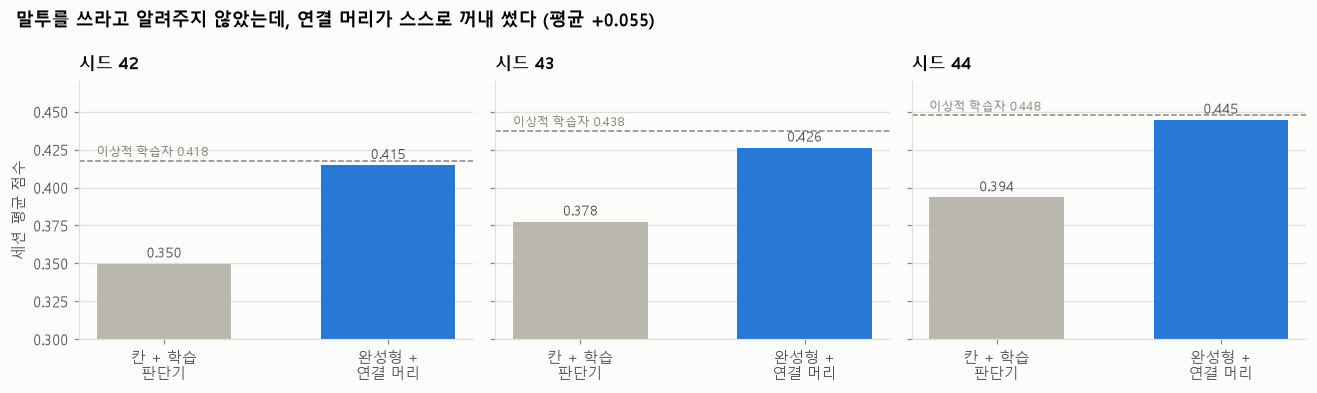

In [2]:

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, seed in zip(axes, SEEDS):
    b = base[str(seed)]
    bars = [("칸 + 학습\n판단기", b["n2_designed_format"], V.NEUTRAL),
            ("완성형 +\n연결 머리", runs[seed]["test_score"], V.BLUE)]
    for i, (label, value, color) in enumerate(bars):
        ax.bar(i, value, width=0.6, color=color)
        ax.text(i, value + 0.004, f"{value:.3f}", ha="center", fontsize=9, color=V.TEXT_SECONDARY)
    ax.axhline(b["learner+cue"], color=V.MUTED, linestyle="--", linewidth=1)
    ax.text(-0.3, b["learner+cue"] + 0.003, f"이상적 학습자 {b['learner+cue']:.3f}", ha="left", fontsize=8, color=V.MUTED)
    ax.set_xticks(range(2), [l for l, _, _ in bars])
    ax.set_ylim(0.30, 0.47)
    ax.grid(axis="x", visible=False)
    ax.set_title(f"시드 {seed}", fontsize=11, pad=8)
axes[0].set_ylabel("세션 평균 점수")
fig.suptitle(f"말투를 쓰라고 알려주지 않았는데, 연결 머리가 스스로 꺼내 썼다 (평균 +{mean:.3f})",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()



## 2. 정말 말투 덕분일까? 말투를 지워 본다

시험할 때 각 문장의 메시지를 **말투를 뗀 같은 문장**의 메시지로 바꿨다. 이득이 말투에서 왔다면 점수가 칸 방식 수준으로 떨어져야 한다.


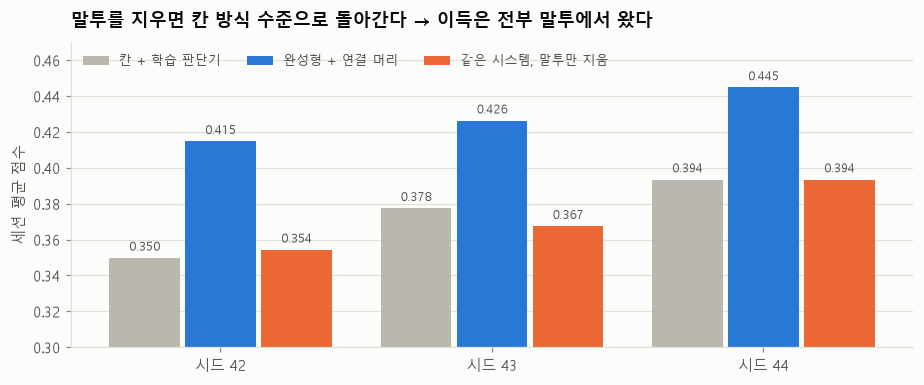

In [3]:

import numpy as np
fig, ax = plt.subplots(figsize=(8.5, 3.6))
x = np.arange(len(SEEDS))
series = [("칸 + 학습 판단기", [base[str(s)]["n2_designed_format"] for s in SEEDS], V.NEUTRAL),
          ("완성형 + 연결 머리", [analysis[str(s)]["test"] for s in SEEDS], V.BLUE),
          ("같은 시스템, 말투만 지움", [analysis[str(s)]["cue_removed"] for s in SEEDS], V.ORANGE)]
width = 0.26
for i, (label, values, color) in enumerate(series):
    ax.bar(x + (i - 1) * (width + 0.02), values, width=width, color=color, label=label)
    for xi, v in zip(x, values):
        ax.text(xi + (i - 1) * (width + 0.02), v + 0.004, f"{v:.3f}", ha="center", fontsize=8, color=V.TEXT_SECONDARY)
ax.set_xticks(x, [f"시드 {s}" for s in SEEDS])
ax.set_ylim(0.30, 0.47)
ax.grid(axis="x", visible=False)
ax.set_ylabel("세션 평균 점수")
ax.legend(loc="upper left", fontsize=8.5, frameon=False, ncol=3)
ax.set_title("말투를 지우면 칸 방식 수준으로 돌아간다 → 이득은 전부 말투에서 왔다", pad=10)
fig.tight_layout()
plt.show()



## 3. 정보는 어디서 버려지고 있었나

선형 탐침으로 "이 메시지에서 말투를 알아낼 수 있나"를 봤다. 평가는 학습에 쓰지 않은 문장으로 하고, 각 문장이 말하는 (문, 열쇠) 쌍만 본다. 찍기 수준은 약 0.43이다.


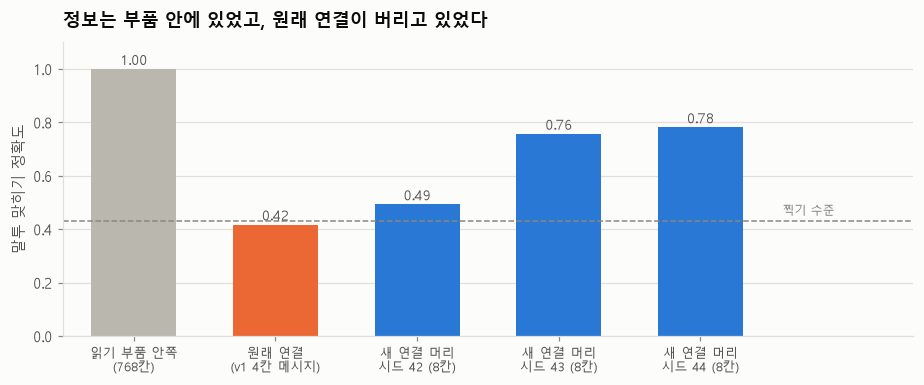

In [4]:

values = [("읽기 부품 안쪽\n(768칸)", analysis["feature_probe_claim_pair"], V.NEUTRAL),
          ("원래 연결\n(v1 4칸 메시지)", analysis["v1_message_probe_claim_pair"], V.ORANGE)]
values += [(f"새 연결 머리\n시드 {s} (8칸)", analysis[str(s)]["probe_claim_pair"], V.BLUE) for s in SEEDS]
fig, ax = plt.subplots(figsize=(8.5, 3.6))
for i, (label, v, color) in enumerate(values):
    ax.bar(i, v, width=0.6, color=color)
    ax.text(i, v + 0.015, f"{v:.2f}", ha="center", fontsize=9, color=V.TEXT_SECONDARY)
ax.axhline(0.43, color=V.MUTED, linestyle="--", linewidth=1)
ax.set_xlim(-0.5, len(values) + 0.5)
ax.text(len(values) - 0.42, 0.445, "찍기 수준", ha="left", va="bottom", fontsize=8, color=V.MUTED)
ax.set_xticks(range(len(values)), [l for l, _, _ in values], fontsize=8.5)
ax.set_ylim(0, 1.1)
ax.grid(axis="x", visible=False)
ax.set_ylabel("말투 맞히기 정확도")
ax.set_title("정보는 부품 안에 있었고, 원래 연결이 버리고 있었다", pad=10)
fig.tight_layout()
plt.show()



- 시드 42는 선형 탐침 값이 낮다(0.49). 하지만 긍정 문장과 부정 문장을 **따로** 보면 말투를 0.76, 0.99로 맞힌다. 이 시드는 말투를 "긍정/부정과 섞인 방향"으로 담았고, 직선 하나로는 안 갈린다. 말투를 지웠을 때 점수가 떨어진 것(2번)이 이 정보를 실제로 쓴다는 직접 증거다.

## 4. 정리

- **1단계 졸업.** 시드 3개 모두 칸 방식보다 높았다(+0.065, +0.049, +0.051). 평균은 **+0.055**이고, 95% 신뢰구간은 [+0.033, +0.077]이다.
- 말투 공식을 미리 아는 이상적 학습자와의 차이는 0.003–0.011뿐이다. 정답만 보고 말투의 의미를 거의 완전히 배웠다.
- 학습한 것은 연결 머리 6,152개와 기억·판단 19,361개다. 읽기 부품 본체(약 2.8억 개)는 얼렸다. 시드 하나에 32분, GPU 메모리 1GB 미만이었다.
- **교훈**: 정보는 큰 부품 안에 이미 있었다. 성능을 가른 것은 **무엇을 어떻게 넘기느냐(연결)**였다.
